In [13]:
import os

# Create all folders
project_path = os.path.join(os.path.expanduser("~"), "Desktop", "Ecommerce_Sales_Project")

folders = ["data", "images", "sql", "dashboard", "notebooks"]
for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)
    print(f"✅ Created: {folder}")

print("\n📁 Project folder created at:")
print(project_path)

✅ Created: data
✅ Created: images
✅ Created: sql
✅ Created: dashboard
✅ Created: notebooks

📁 Project folder created at:
C:\Users\PRIYANKA MANDAPPA\Desktop\Ecommerce_Sales_Project


In [14]:
import os

data_path = os.path.join(os.path.expanduser("~"), "Desktop", "Ecommerce_Sales_Project", "data")

print("Files in data folder:")
for f in os.listdir(data_path):
    print("  →", f)

Files in data folder:
  → Sample - Superstore.xls


In [15]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set paths
project_path = os.path.join(os.path.expanduser("~"), "Desktop", "Ecommerce_Sales_Project")
data_path = os.path.join(project_path, "data")
images_path = os.path.join(project_path, "images")

# Install xlrd for .xls files
import subprocess
subprocess.check_call(["pip", "install", "xlrd", "--quiet"])

# Load dataset
file_path = os.path.join(data_path, "Sample - Superstore.xls")
df = pd.read_excel(file_path, sheet_name="Orders")

print("✅ Dataset loaded!")
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

✅ Dataset loaded!
Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
# Check columns and data types
print("Columns:")
print(list(df.columns))

print("\nFirst 5 rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df[['Sales', 'Profit', 'Quantity', 'Discount']].describe())

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2013-152156 2013-11-09 2013-11-12    Second Class    CG-12520   
1       2  CA-2013-152156 2013-11-09 2013-11-12    Second Class    CG-12520   
2       3  CA-2013-138688 2013-06-13 2013-06-17    Second Class    DV-13045   
3       4  US-2012-108966 2012-10-11 2012-10-18  Standard Class    SO-20335   
4       5  US-2012-108966 2012-10-11 2012-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  

In [17]:
print("=" * 55)
print("       ECOMMERCE SALES — KEY METRICS")
print("=" * 55)

print(f"\n📦 Total Orders: {df['Order ID'].nunique()}")
print(f"👥 Total Customers: {df['Customer ID'].nunique()}")
print(f"💰 Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"📈 Total Profit: ${df['Profit'].sum():,.2f}")
print(f"🛒 Total Items Sold: {df['Quantity'].sum():,}")
print(f"📊 Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.1f}%")

print("\n🗂️ Categories:")
print(df['Category'].value_counts())

print("\n🌍 Regions:")
print(df['Region'].value_counts())

print("\n📅 Date Range:")
print(f"From: {df['Order Date'].min()}")
print(f"To:   {df['Order Date'].max()}")
print("=" * 55)

       ECOMMERCE SALES — KEY METRICS

📦 Total Orders: 5009
👥 Total Customers: 793
💰 Total Revenue: $2,297,200.86
📈 Total Profit: $286,397.02
🛒 Total Items Sold: 37,873
📊 Profit Margin: 12.5%

🗂️ Categories:
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

🌍 Regions:
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

📅 Date Range:
From: 2011-01-04 00:00:00
To:   2014-12-31 00:00:00


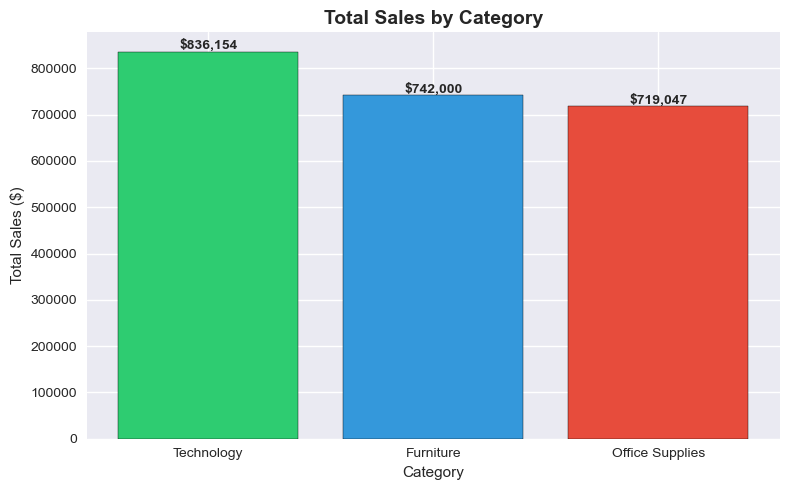

✅ Chart saved!


In [18]:
plt.style.use('seaborn-v0_8')

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(category_sales.index, category_sales.values, 
               color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='black')

# Add value labels on bars
for bar, val in zip(bars, category_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig(os.path.join(images_path, '01_sales_by_category.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

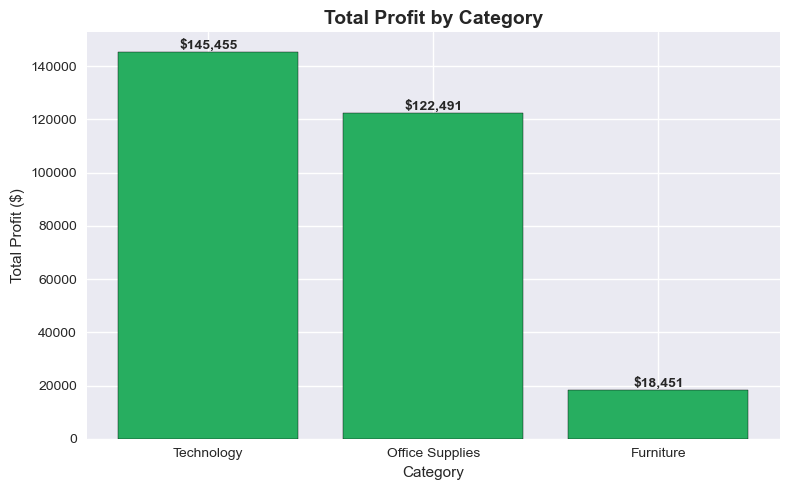

✅ Chart saved!


In [19]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colors = ['#27ae60' if x > 0 else '#e74c3c' for x in category_profit.values]
bars = plt.bar(category_profit.index, category_profit.values,
               color=colors, edgecolor='black')

for bar, val in zip(bars, category_profit.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.title('Total Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig(os.path.join(images_path, '02_profit_by_category.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

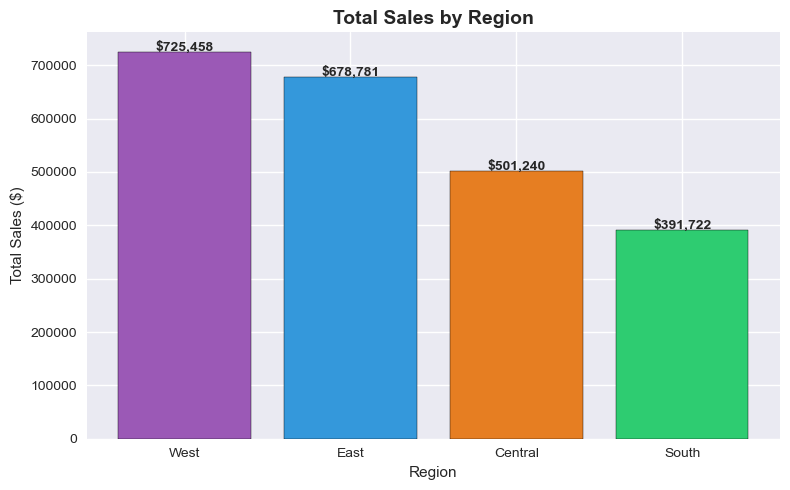

✅ Chart saved!


In [20]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(region_sales.index, region_sales.values,
               color=['#9b59b6', '#3498db', '#e67e22', '#2ecc71'], edgecolor='black')

for bar, val in zip(bars, region_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
             f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig(os.path.join(images_path, '03_sales_by_region.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

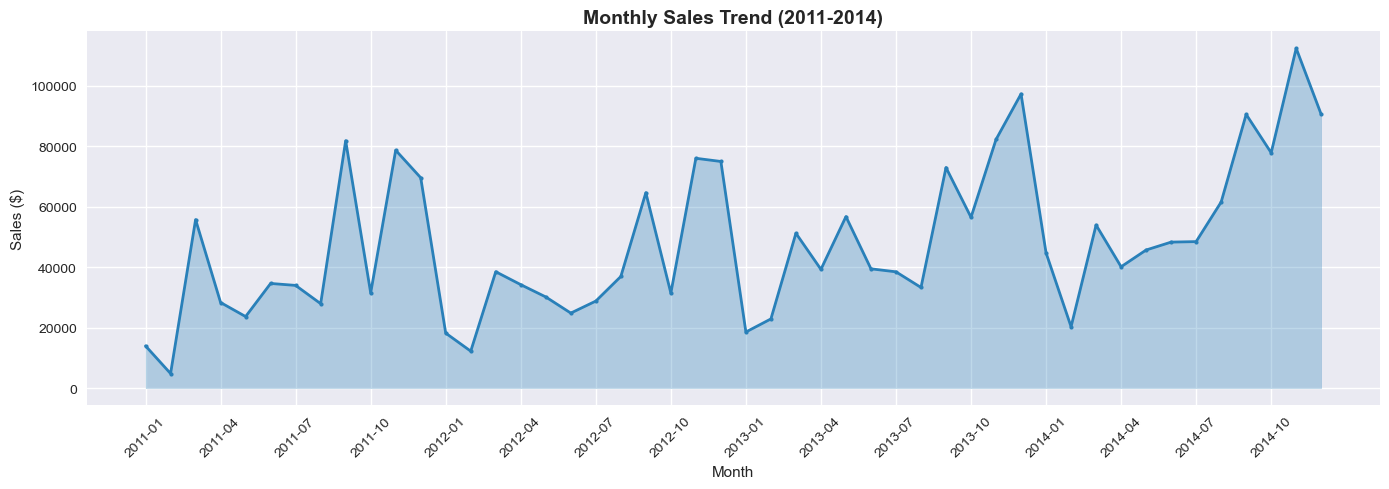

✅ Chart saved!


In [21]:
# Extract year and month
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['Sales'].sum()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values,
         color='#2980b9', linewidth=2, marker='o', markersize=3)
plt.fill_between(range(len(monthly_sales)), monthly_sales.values,
                 alpha=0.3, color='#2980b9')
plt.title('Monthly Sales Trend (2011-2014)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(0, len(monthly_sales), 3),
           [str(x) for x in monthly_sales.index[::3]], rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(images_path, '04_monthly_sales_trend.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

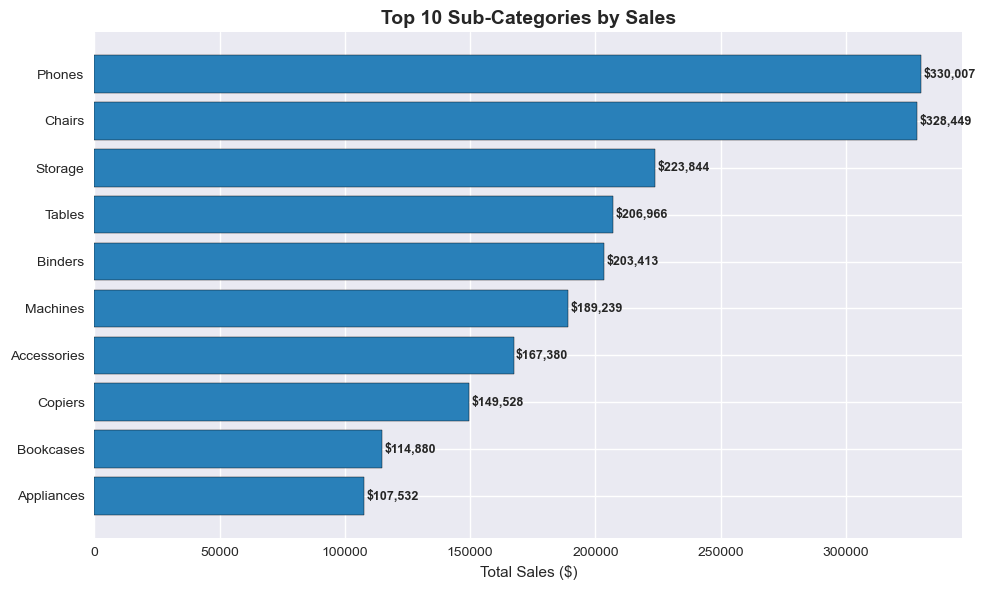

✅ Chart saved!


In [22]:
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(sub_sales.index, sub_sales.values, color='#2980b9', edgecolor='black')

for bar, val in zip(bars, sub_sales.values):
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')

plt.title('Top 10 Sub-Categories by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig(os.path.join(images_path, '05_top_subcategories.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

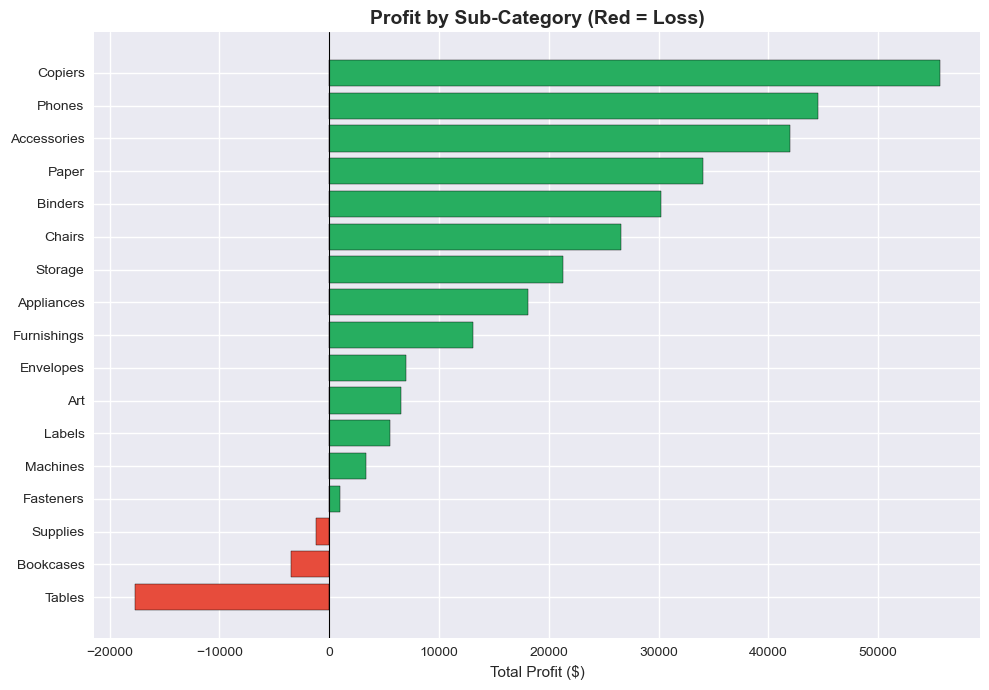

✅ Chart saved!


In [23]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if x < 0 else '#27ae60' for x in sub_profit.values]
plt.barh(sub_profit.index, sub_profit.values, color=colors, edgecolor='black')

plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Profit by Sub-Category (Red = Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig(os.path.join(images_path, '06_profit_by_subcategory.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

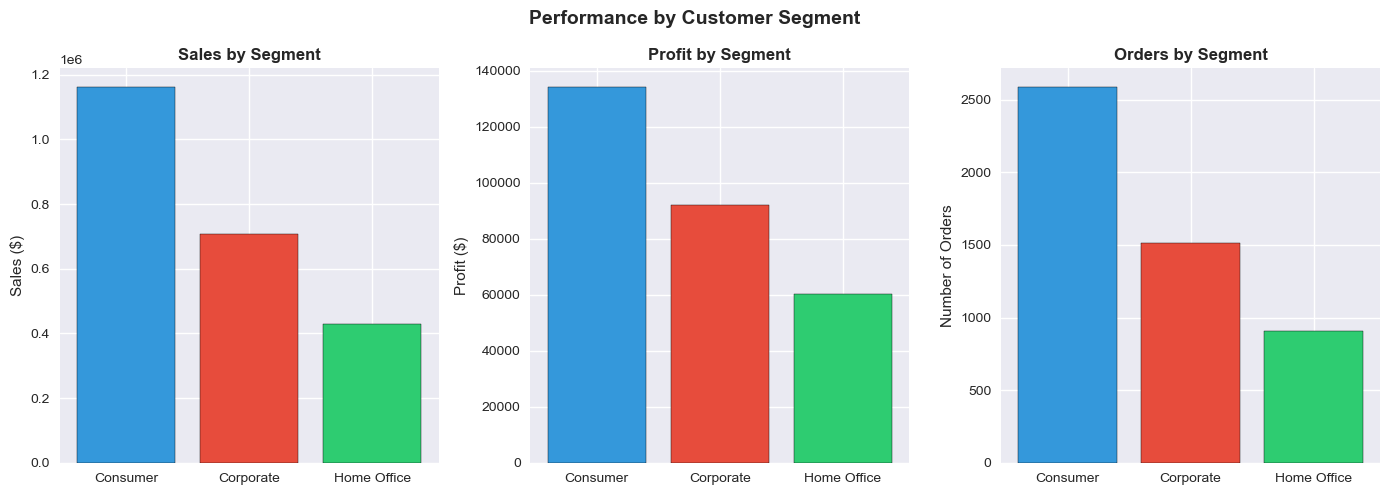

✅ Chart saved!


In [24]:
segment_data = df.groupby('Segment').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Sales
axes[0].bar(segment_data['Segment'], segment_data['Sales'],
            color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Sales by Segment', fontweight='bold')
axes[0].set_ylabel('Sales ($)')

# Profit
axes[1].bar(segment_data['Segment'], segment_data['Profit'],
            color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Profit by Segment', fontweight='bold')
axes[1].set_ylabel('Profit ($)')

# Orders
axes[2].bar(segment_data['Segment'], segment_data['Orders'],
            color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[2].set_title('Orders by Segment', fontweight='bold')
axes[2].set_ylabel('Number of Orders')

plt.suptitle('Performance by Customer Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(images_path, '07_segment_analysis.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

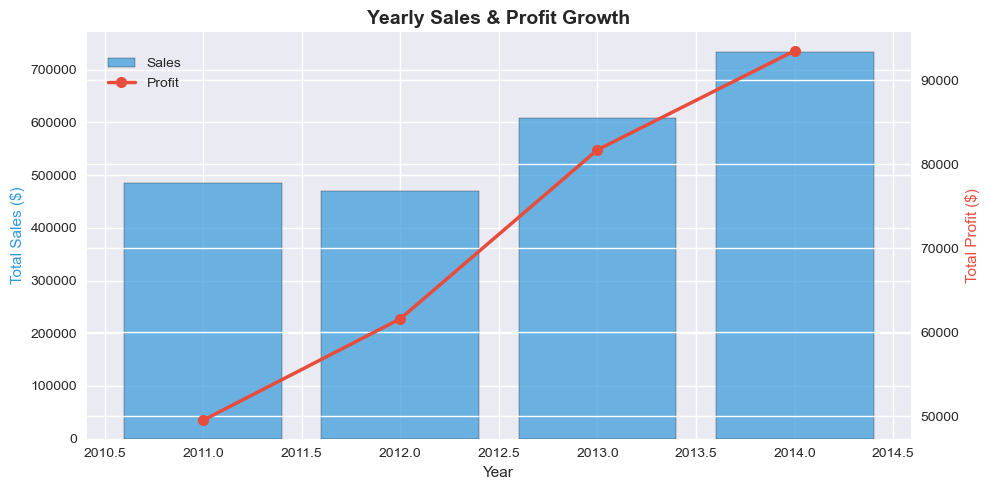

✅ Chart saved!


In [25]:
yearly_sales = df.groupby('Year').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(yearly_sales['Year'], yearly_sales['Sales'],
        color='#3498db', alpha=0.7, edgecolor='black', label='Sales')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Sales ($)', color='#3498db')

ax2 = ax1.twinx()
ax2.plot(yearly_sales['Year'], yearly_sales['Profit'],
         color='#e74c3c', linewidth=2.5, marker='o', markersize=8, label='Profit')
ax2.set_ylabel('Total Profit ($)', color='#e74c3c')

plt.title('Yearly Sales & Profit Growth', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig(os.path.join(images_path, '08_yearly_growth.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

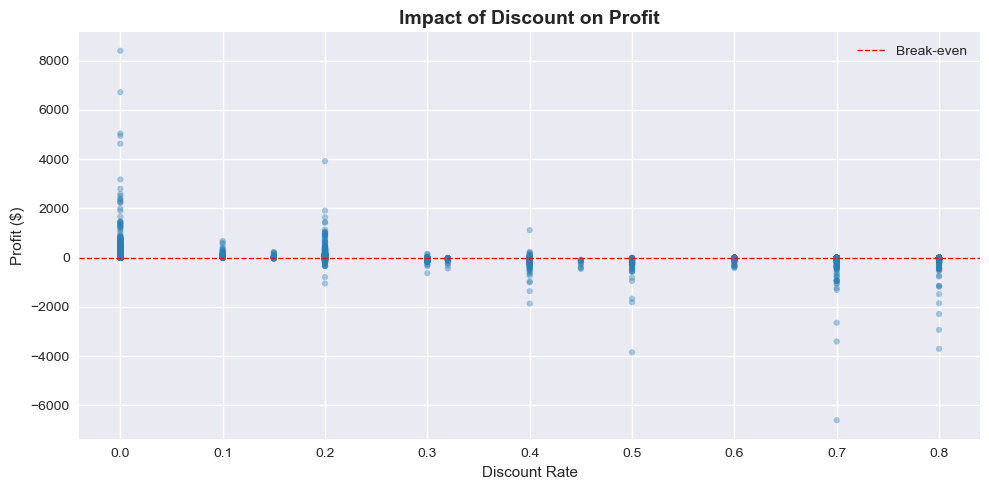

✅ Chart saved!


In [26]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Discount'], df['Profit'], 
            alpha=0.4, color='#2980b9', edgecolor='none', s=20)
plt.axhline(y=0, color='red', linewidth=1, linestyle='--', label='Break-even')
plt.title('Impact of Discount on Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(images_path, '09_discount_vs_profit.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

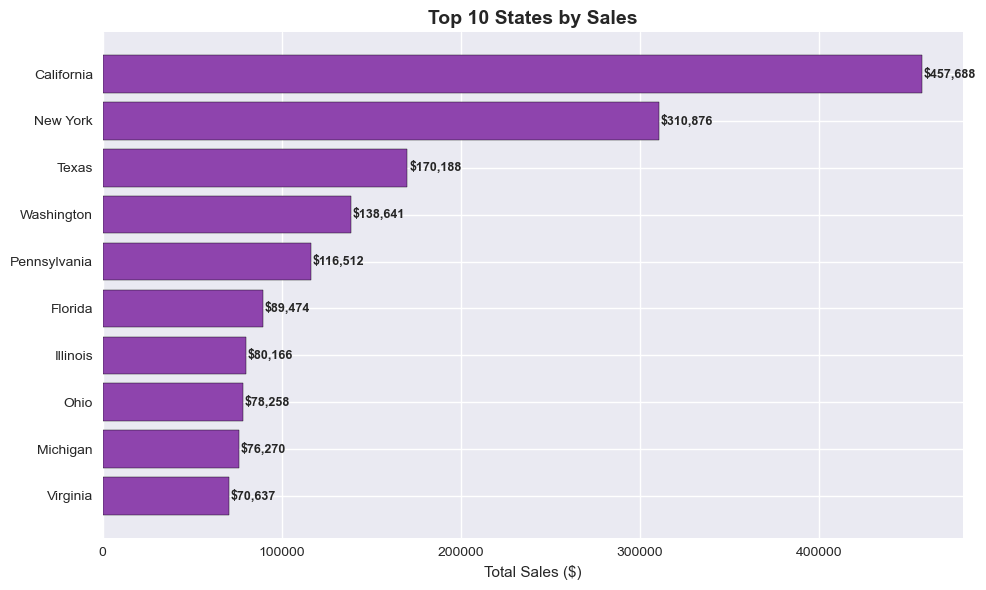

✅ Chart saved!


In [27]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(state_sales.index, state_sales.values,
                color='#8e44ad', edgecolor='black')

for bar, val in zip(bars, state_sales.values):
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')

plt.title('Top 10 States by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig(os.path.join(images_path, '10_top_states.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

In [28]:
print("=" * 60)
print("     ECOMMERCE SALES ANALYSIS — KEY INSIGHTS")
print("=" * 60)

print(f"\n💰 Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"📈 Total Profit: ${df['Profit'].sum():,.2f}")
print(f"📊 Overall Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.1f}%")
print(f"📦 Total Orders: {df['Order ID'].nunique():,}")
print(f"👥 Total Customers: {df['Customer ID'].nunique():,}")

print("\n🏆 Best Performing Category:")
best_cat = df.groupby('Category')['Profit'].sum().idxmax()
print(f"   {best_cat}: ${df.groupby('Category')['Profit'].sum().max():,.2f}")

print("\n❌ Loss Making Sub-Categories:")
loss = df.groupby('Sub-Category')['Profit'].sum()
for name, val in loss[loss < 0].items():
    print(f"   {name}: ${val:,.2f}")

print("\n🌍 Best Region:")
best_region = df.groupby('Region')['Sales'].sum().idxmax()
print(f"   {best_region}: ${df.groupby('Region')['Sales'].sum().max():,.2f}")

print("\n📅 Best Year:")
best_year = df.groupby('Year')['Sales'].sum().idxmax()
print(f"   {best_year}: ${df.groupby('Year')['Sales'].sum().max():,.2f}")

print("\n🏆 Top State:")
top_state = df.groupby('State')['Sales'].sum().idxmax()
print(f"   {top_state}: ${df.groupby('State')['Sales'].sum().max():,.2f}")

print("\n⚠️ Discount Impact:")
high_discount = df[df['Discount'] >= 0.4]
print(f"   Orders with 40%+ discount: {len(high_discount)}")
print(f"   Total loss from high discounts: ${high_discount['Profit'].sum():,.2f}")
print("=" * 60)

     ECOMMERCE SALES ANALYSIS — KEY INSIGHTS

💰 Total Revenue: $2,297,200.86
📈 Total Profit: $286,397.02
📊 Overall Profit Margin: 12.5%
📦 Total Orders: 5,009
👥 Total Customers: 793

🏆 Best Performing Category:
   Technology: $145,454.95

❌ Loss Making Sub-Categories:
   Bookcases: $-3,472.56
   Supplies: $-1,189.10
   Tables: $-17,725.48

🌍 Best Region:
   West: $725,457.82

📅 Best Year:
   2014: $733,947.02

🏆 Top State:
   California: $457,687.63

⚠️ Discount Impact:
   Orders with 40%+ discount: 1139
   Total loss from high discounts: $-122,615.64


In [29]:
# Save cleaned dataset
df.to_csv(os.path.join(data_path, "superstore_clean.csv"), index=False)
print("✅ Clean dataset saved!")

✅ Clean dataset saved!
